In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os
import libf0
os.chdir(r"C:\Users\thant\OneDrive\Documents\Master Thesises\MosSongPlus")
from src.io.loader import audio_loader

In [2]:
audio_path = r"dataset\Philip\Lab\Ae. aegypti_M_5.wav"
data = audio_loader(audio_path, dc_removal=True)

In [3]:
data

array([-1.0838348e-04, -1.2586828e-04, -3.6891895e-05, ...,
        3.5673027e-05, -7.0957499e-06,  2.5597114e-05],
      shape=(1502163,), dtype=float32)

In [10]:
def waveform_analysis(data, sr: int) -> dict:
    # data = data[0:int(sr * 0.3)]

    librosa.display.waveshow(data, sr=sr)
    plt.title("Audio Signal")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

    duration = librosa.get_duration(y=data, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y=data)
    rms = librosa.feature.rms(y=data)
    spec_centroid = librosa.feature.spectral_centroid(y=data, sr=sr)
    spec_bandwidth = librosa.feature.spectral_bandwidth(y=data, sr=sr)
    spec_contrast = librosa.feature.spectral_contrast(y=data, sr=sr, fmin=50)
    spec_rolloff = librosa.feature.spectral_rolloff(y=data, sr=sr)
    spec_flatness = librosa.feature.spectral_flatness(y=data)
    result = {
        "sample_rate": sr,
        "duration_sec": duration,
        "zero_crossing_rate_mean": float(np.mean(zcr)),
        "rms_energy_mean": float(np.mean(rms)),
        "spectral_centroid_mean": float(np.mean(spec_centroid)),
        "spectral_bandwidth_mean": float(np.mean(spec_bandwidth)),
        "spectral_contrast_mean": float(np.mean(spec_contrast)),
        "spectral_rolloff_mean": float(np.mean(spec_rolloff)),
        "spectral_flatness_mean": float(np.mean(spec_flatness)),
    }

    for key, value in result.items():
        print(f"{key}: {value}")

    return result

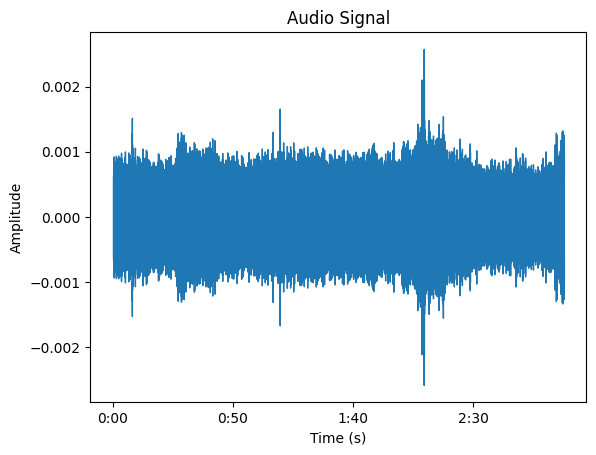

sample_rate: 8000
duration_sec: 187.770375
zero_crossing_rate_mean: 0.11146309299377982
rms_energy_mean: 0.00027232494903728366
spectral_centroid_mean: 862.1249458662014
spectral_bandwidth_mean: 938.6703894464545
spectral_contrast_mean: 15.238382808618631
spectral_rolloff_mean: 1770.3487133606
spectral_flatness_mean: 0.04273505508899689


{'sample_rate': 8000,
 'duration_sec': 187.770375,
 'zero_crossing_rate_mean': 0.11146309299377982,
 'rms_energy_mean': 0.00027232494903728366,
 'spectral_centroid_mean': 862.1249458662014,
 'spectral_bandwidth_mean': 938.6703894464545,
 'spectral_contrast_mean': 15.238382808618631,
 'spectral_rolloff_mean': 1770.3487133606,
 'spectral_flatness_mean': 0.04273505508899689}

In [11]:
waveform_analysis(data, sr=8000)